# Transformation - Binning - Binarization - EDA


In [4]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 

In [5]:
df=pd.read_csv('../datasets/customer_health_insurance.csv')
df.sample(3)

,Customer_ID,Age,BMI,Annual_Income,Medical_Bill,Gender,Smoking_Status,City,Education,Health_Score,Insurance
70,10071,57.0,30.4,40978.0,14762.0,Female,Former,Lahore,Master,Average,No
947,10948,28.0,22.6,28698.0,14161.0,Female,Never,Lahore,Master,Good,No
833,10834,43.0,31.9,134744.0,34659.0,Female,Never,Islamabad,PhD,Good,Yes


In [6]:
df['Education'].value_counts()


Education
Bachelor    512
Master      331
PhD         151
Name: count, dtype: int64

In [7]:
df.shape # 1000 ,11 
df.isnull().sum()

Customer_ID        0
Age               15
BMI               12
Annual_Income     10
Medical_Bill      10
Gender             8
Smoking_Status     8
City               7
Education          6
Health_Score       6
Insurance          0
dtype: int64

In [8]:
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Customer_ID     1000 non-null   int64  
 1   Age             985 non-null    float64
 2   BMI             988 non-null    float64
 3   Annual_Income   990 non-null    float64
 4   Medical_Bill    990 non-null    float64
 5   Gender          992 non-null    str    
 6   Smoking_Status  992 non-null    str    
 7   City            993 non-null    str    
 8   Education       994 non-null    str    
 9   Health_Score    994 non-null    str    
 10  Insurance       1000 non-null   str    
dtypes: float64(4), int64(1), str(6)
memory usage: 86.1 KB


,Customer_ID,Age,BMI,Annual_Income,Medical_Bill
count,1000.000000,985.000000,988.000000,990.000000,990.000000
mean,10500.500000,44.448731,27.092510,79231.050505,23952.169697
std,288.819436,15.348912,5.276762,61685.228326,19991.597414
min,10001.000000,18.000000,9.200000,9082.000000,1588.000000
25%,10250.750000,32.000000,23.800000,40502.750000,11010.250000
50%,10500.500000,45.000000,27.300000,63637.000000,18383.000000
75%,10750.250000,57.000000,30.700000,98152.750000,29861.000000
max,11000.000000,70.000000,42.900000,605928.000000,187479.000000


In [9]:
df.drop(columns=['Customer_ID'],inplace=True)

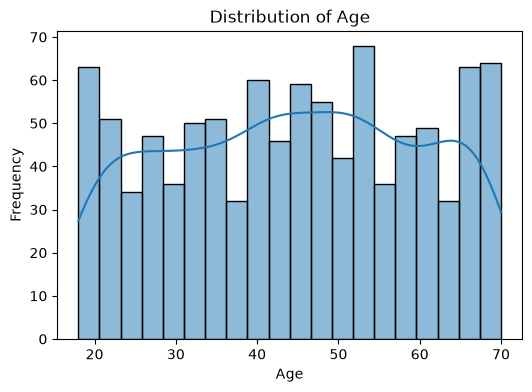

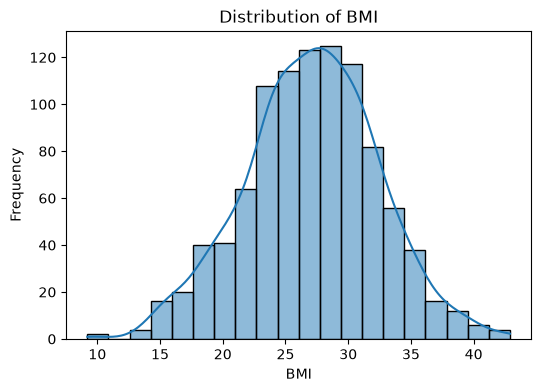

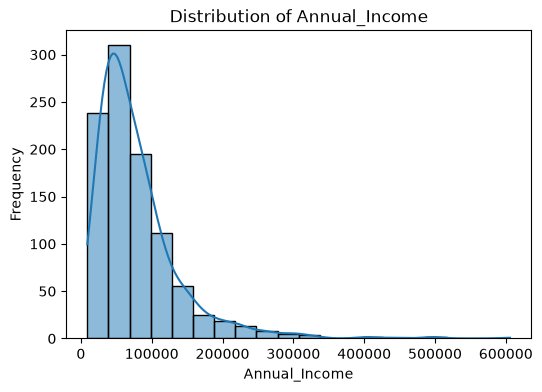

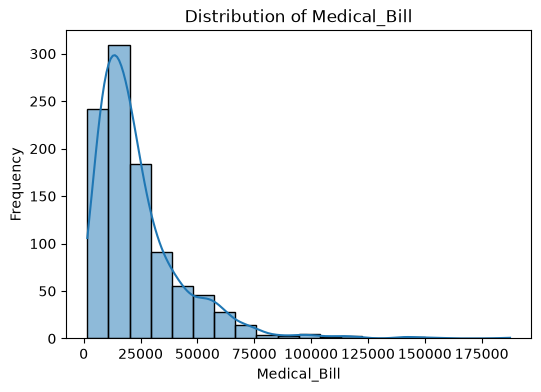

In [10]:
num_cols = ['Age', 'BMI', 'Annual_Income', 'Medical_Bill']

for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True, bins=20)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

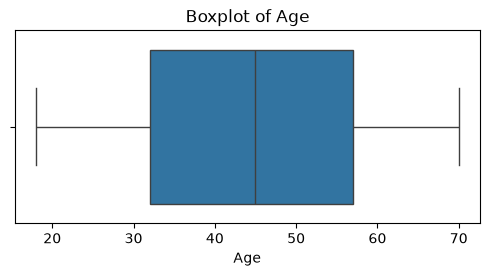

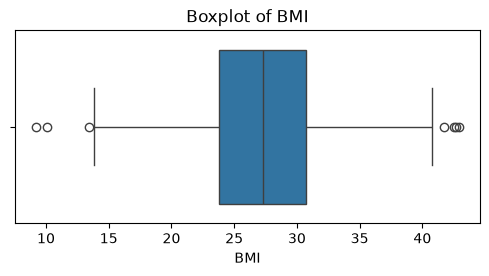

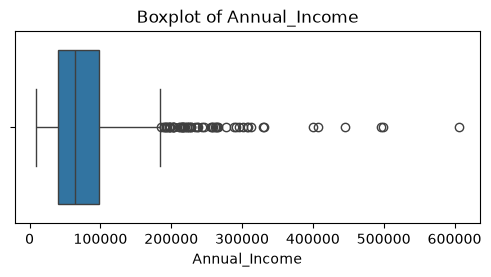

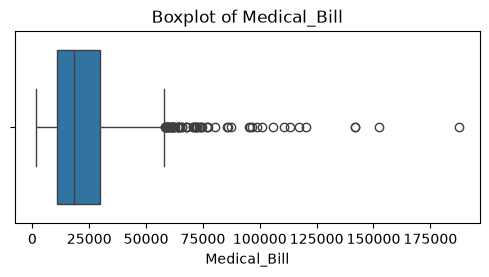

In [11]:
num_cols = ['Age', 'BMI', 'Annual_Income', 'Medical_Bill']

for col in num_cols:
    plt.figure(figsize=(6, 2.5))
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
    plt.show()

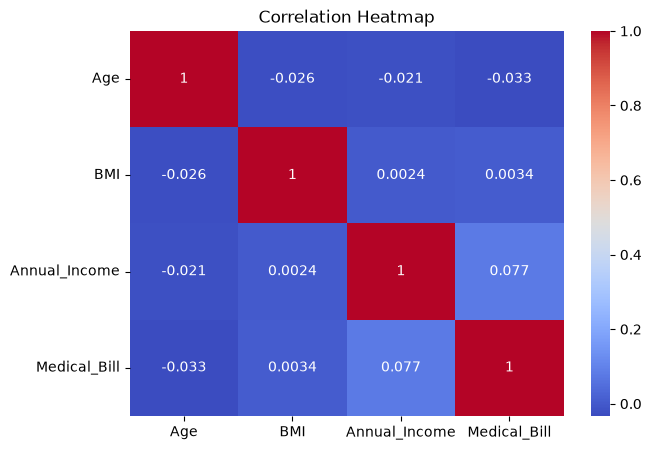

In [12]:
plt.figure(figsize=(7, 5))

sns.heatmap(
    df[['Age', 'BMI', 'Annual_Income', 'Medical_Bill']].corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Heatmap')
plt.show()

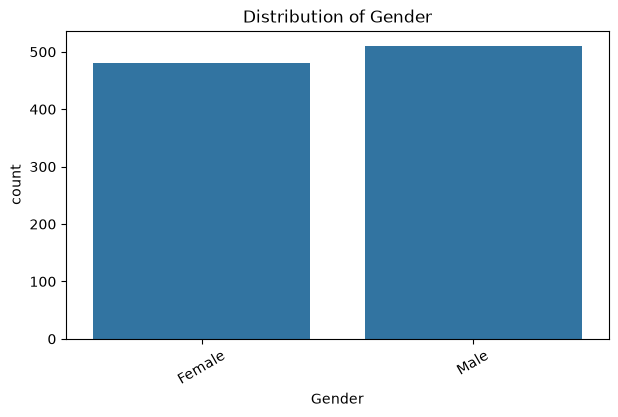

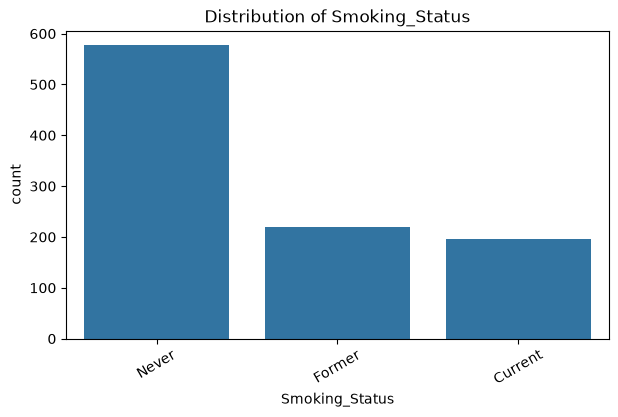

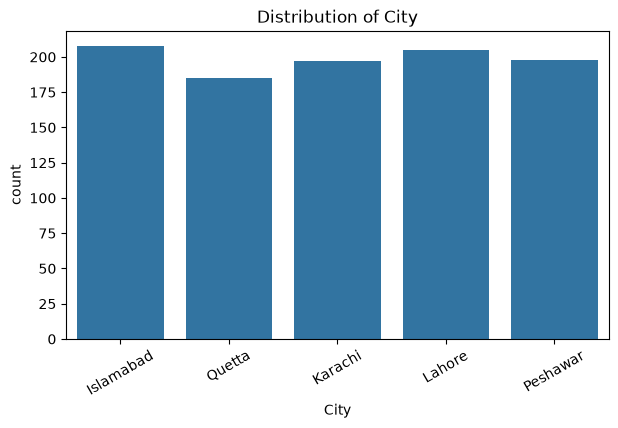

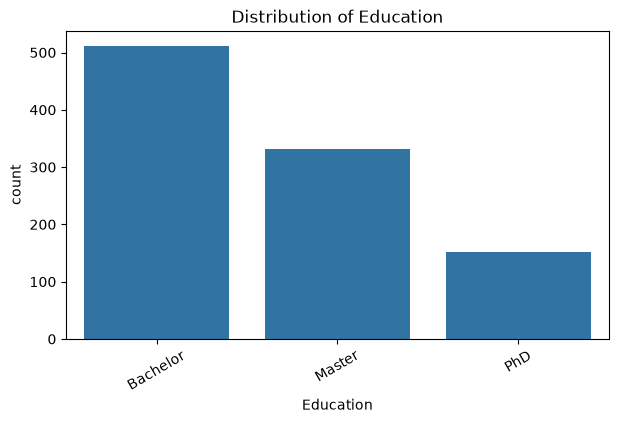

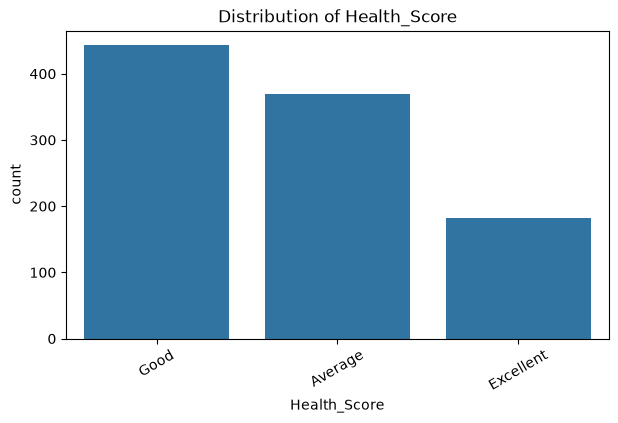

In [13]:
cat_cols = ['Gender', 'Smoking_Status', 'City', 'Education', 'Health_Score']
for col in cat_cols:
    plt.figure(figsize=(7, 4))
    sns.countplot(data=df, x=col)
    plt.title(f'Distribution of {col}')
    plt.xticks(rotation=30)
    plt.show()

In [14]:
X=df.drop(columns=['Insurance'])
Y=df['Insurance']

In [15]:
from sklearn.model_selection import train_test_split

X_train , X_test , Y_train ,Y_test = train_test_split(X,Y,test_size=0.3,random_state=42)


In [16]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import FunctionTransformer
from sklearn.preprocessing import StandardScaler

skew_num_pip=Pipeline([
    ('imputer',SimpleImputer(strategy='mean')),
    ('transformer',FunctionTransformer(np.log1p)),
    ('scalar',StandardScaler())
])


In [17]:
from sklearn.preprocessing import KBinsDiscretizer
age_binning_pip=Pipeline([
    ('imputer',SimpleImputer(strategy='mean')),
    ('binning',KBinsDiscretizer(
        n_bins=5,
        strategy='uniform',
        encode='ordinal'
    ))
])

In [18]:
from sklearn.preprocessing import Binarizer

bmi_bin_pip=Pipeline([
    ('imputer',SimpleImputer(strategy='mean')),
    ('binirization',Binarizer(threshold=27.30))
])

In [19]:
from sklearn.preprocessing import OneHotEncoder
nom_pip=Pipeline([
    ('imputer',SimpleImputer(strategy='most_frequent')),
    ('ohe',OneHotEncoder())
])

In [20]:
from sklearn.preprocessing import OrdinalEncoder
ord_pip=Pipeline([
    ('imputer',SimpleImputer(strategy='most_frequent')),
    ('ord',OrdinalEncoder(categories=[['Bachelor','Master','PhD'],['Average','Good','Excellent']]))
    
])

In [22]:
skewed_num_cols = ['Annual_Income', 'Medical_Bill']

age_bin_cols = ['Age']

bmi_bin_cols = ['BMI']

nominal_cols = ['Gender', 'Smoking_Status', 'City']

ordinal_cols = ['Education', 'Health_Score']

In [23]:
from sklearn.compose import ColumnTransformer

preprocessing=ColumnTransformer([
    ('Skew_num',skew_num_pip,skewed_num_cols),
    ('age_bining',age_binning_pip,age_bin_cols),
    ('bmi_bin',bmi_bin_pip,bmi_bin_cols),
    ('nominal',nom_pip,nominal_cols),
    ('ord',ord_pip,ordinal_cols)
])

In [24]:
from sklearn.linear_model import LogisticRegression

model=Pipeline([
    ('Preprocess',preprocessing),
    ('classifier',LogisticRegression(class_weight='balanced', solver='lbfgs', max_iter=1000))
])

In [25]:
model.fit(X_train,Y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('Preprocess', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[object](2,)","['No','Yes']"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](9,)","['Age','BMI','Annual_Income',...,'City','Education','Health_Score']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,9
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('Skew_num', ...), ('age_bining', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder

In [26]:
y_prediction = model.predict(X_test)

In [27]:
from sklearn.metrics import accuracy_score

model_accuracy=accuracy_score(y_prediction,Y_test)
print(f'Model Accuracy is {model_accuracy*100} %')

Model Accuracy is 60.66666666666667 %


In [28]:
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import cross_val_score


# Confusion Matrix
print("=== Confusion Matrix ===")
print(confusion_matrix(Y_test, y_prediction))



=== Confusion Matrix ===
[[ 60  56]
 [ 62 122]]


In [29]:
# Classification Report (Precision, Recall, F1-Score)
print("\n=== Classification Report ===")
print(classification_report(Y_test, y_prediction))




=== Classification Report ===
              precision    recall  f1-score   support

          No       0.49      0.52      0.50       116
         Yes       0.69      0.66      0.67       184

    accuracy                           0.61       300
   macro avg       0.59      0.59      0.59       300
weighted avg       0.61      0.61      0.61       300



In [30]:

cv_scores = cross_val_score(model, X, Y, cv=5, scoring='accuracy')

print("\nCross-Validation Results ")
print("All 5 Fold Scores:", cv_scores)
print("Mean Accuracy:", cv_scores.mean())
print("Standard Deviation:", cv_scores.std())


Cross-Validation Results 
All 5 Fold Scores: [0.71  0.655 0.67  0.62  0.56 ]
Mean Accuracy: 0.643
Standard Deviation: 0.05055689863905813


In [31]:
from sklearn.model_selection import GridSearchCV
param_grid = {
    'classifier__C': [0.01, 0.1, 1, 10, 100]
}

grid_search = GridSearchCV(
    model,
    param_grid,
    cv=5,
    scoring='accuracy'
)

In [32]:
grid_search.fit(X_train, Y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step..._iter=1000))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'classifier__C': [0.01, 0.1, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls the verbosity of information printed during fi

In [34]:
print(grid_search.best_params_)
print(grid_search.best_score_)

{'classifier__C': 0.1}
0.667142857142857


In [40]:
y_prediction = grid_search.predict(X_test)
from sklearn.metrics import accuracy_score

model_accuracy=accuracy_score(y_prediction,Y_test)
print(f'Model Accuracy is {model_accuracy*100} %')

Model Accuracy is 60.0 %


In [31]:
import pickle

In [32]:
with open('../models/health_insurance_model.pkl', 'wb') as file:
    pickle.dump(model, file)

In [33]:
with open('../models/health_insurance_model.pkl', 'rb') as file:
    loaded_model = pickle.load(file)

In [34]:
loaded_model.predict(X_test)

array(['No', 'No', 'No', 'Yes', 'No', 'Yes', 'No', 'Yes', 'No', 'No',
       'No', 'Yes', 'Yes', 'Yes', 'Yes', 'No', 'Yes', 'No', 'Yes', 'No',
       'No', 'Yes', 'Yes', 'No', 'No', 'Yes', 'No', 'No', 'Yes', 'No',
       'No', 'No', 'Yes', 'No', 'Yes', 'No', 'No', 'Yes', 'Yes', 'Yes',
       'Yes', 'No', 'Yes', 'Yes', 'No', 'Yes', 'No', 'Yes', 'No', 'Yes',
       'Yes', 'No', 'Yes', 'Yes', 'Yes', 'Yes', 'Yes', 'No', 'Yes', 'No',
       'Yes', 'No', 'No', 'Yes', 'Yes', 'Yes', 'Yes', 'Yes', 'Yes', 'No',
       'Yes', 'Yes', 'No', 'Yes', 'Yes', 'No', 'No', 'Yes', 'Yes', 'Yes',
       'No', 'Yes', 'Yes', 'Yes', 'No', 'Yes', 'Yes', 'Yes', 'Yes', 'Yes',
       'Yes', 'Yes', 'Yes', 'Yes', 'No', 'Yes', 'No', 'No', 'No', 'No',
       'No', 'Yes', 'No', 'Yes', 'No', 'Yes', 'Yes', 'No', 'Yes', 'No',
       'Yes', 'Yes', 'Yes', 'No', 'Yes', 'Yes', 'No', 'No', 'No', 'No',
       'Yes', 'Yes', 'No', 'Yes', 'Yes', 'Yes', 'Yes', 'No', 'Yes', 'No',
       'No', 'Yes', 'No', 'No', 'Yes', 'Yes', 'No', 'N

In [38]:
# now Implementing on new data set
new_customers = pd.DataFrame({
    'Age': [25, 48, 63],
    'BMI': [22.5, 31.8, 26.2],
    'Annual_Income': [45000, 95000, 70000],
    'Medical_Bill': [2500, 12000, 5500],
    'Gender': ['Female', 'Male', 'Female'],
    'Smoking_Status': ['Never', 'Current', 'Former'],
    'City': ['Islamabad', 'Lahore', 'Karachi'],
    'Education': ['Bachelor', 'Master', 'PhD'],
    'Health_Score': ['Excellent', 'Average', 'Good']
})
loaded_model.predict(new_customers)

array(['No', 'No', 'Yes'], dtype=object)

In [ ]:
# Also Check For Null Values 
new_customer_with_null = pd.DataFrame({
    'Age': [np.nan],
    'BMI': [29.4],
    'Annual_Income': [np.nan],
    'Medical_Bill': [7200],
    'Gender': ['Male'],
    'Smoking_Status': [np.nan],
    'City': ['Islamabad'],
    'Education': ['Master'],
    'Health_Score': [np.nan]
})
loaded_model.predict(new_customer_with_null) 

array(['Yes'], dtype=object)